In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# read data
trash = pd.read_csv('../data/trash_hauler_report.csv')
print(trash.columns)

Index(['Request Number', 'Date Opened', 'Request ', 'Description',
       'Incident Address', 'Zip Code', 'Trash Hauler', 'Trash Route',
       'Council District', 'State Plan X', 'State Plan Y'],
      dtype='object')


In [3]:
# converts requests to string
trash[ 'Request '].astype(str)

0                            Trash - Backdoor
1        Trash - Curbside/Alley Missed Pickup
2        Trash - Curbside/Alley Missed Pickup
3        Trash - Curbside/Alley Missed Pickup
4        Trash - Curbside/Alley Missed Pickup
                         ...                 
20221    Trash - Curbside/Alley Missed Pickup
20222    Trash - Curbside/Alley Missed Pickup
20223    Trash - Curbside/Alley Missed Pickup
20224    Trash - Curbside/Alley Missed Pickup
20225    Trash - Curbside/Alley Missed Pickup
Name: Request , Length: 20226, dtype: object

In [4]:
#filters for Missed in Request and miss in Descrtiption to capture all misssed pickups || (?i) filters case insensitive
missed_pickups = trash.loc[trash['Request '].str.contains('(?i)Missed') | trash['Description'].str.contains('(?i)miss')]

In [5]:
missed_pickups

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
1,25274,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1.721259e+06,685444.799565
2,25276,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209.0,RED RIVER,4205,20.0,1.707027e+06,659887.471571
3,25307,11/01/17,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1.735692e+06,685027.245923
4,25312,11/01/17,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209.0,RED RIVER,4203,20.0,1.710186e+06,664205.101066
7,25327,11/01/17,Trash Collection Complaint,"Trash out on time, miss again Tuesday. ALLEY",1816 Jo Johnston Ave,37203.0,METRO,9208,21.0,1.731459e+06,666013.601229
...,...,...,...,...,...,...,...,...,...,...,...
20221,267125,11/01/19,Trash - Curbside/Alley Missed Pickup,MISSED...NEIGHBORS MISSED,2731 Murfreesboro Pike,37013.0,RED RIVER,4502,32.0,1.781137e+06,632448.551144
20222,267126,11/01/19,Trash - Curbside/Alley Missed Pickup,entire alley,"1621 Long Ave, Nashville, TN 37206, United States",37206.0,METRO,9508,6.0,1.749711e+06,669201.601569
20223,267130,11/01/19,Trash - Curbside/Alley Missed Pickup,missed several,"2943 Windemere Cir, Nashville, TN 37214, Unite...",37214.0,RED RIVER,1502,15.0,1.770293e+06,674936.303809
20224,267134,11/01/19,Trash - Curbside/Alley Missed Pickup,Caller stated trash was missed & were only pic...,"3325 Murfreesboro Pike, Nashville, TN 37013, U...",37013.0,RED RIVER,4502,32.0,1.785225e+06,627146.400187


In [6]:
# filters haulers for Red River only
RRWS_missed = missed_pickups.loc[trash['Trash Hauler'].notna() & trash['Trash Hauler'].str.contains('RED RIVER')]

In [7]:
RRWS_missed

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
1,25274,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1.721259e+06,685444.799565
2,25276,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209.0,RED RIVER,4205,20.0,1.707027e+06,659887.471571
4,25312,11/01/17,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209.0,RED RIVER,4203,20.0,1.710186e+06,664205.101066
8,25330,11/01/17,Trash - Curbside/Alley Missed Pickup,Missed.,4484 Lavergne Couchville Pike,37013.0,RED RIVER,4210,33.0,1.794534e+06,618749.342732
10,25341,11/01/17,Trash - Curbside/Alley Missed Pickup,Missed trash pickup - resident has at curb for...,3113 HYDES FERRY RD,37218.0,RED RIVER,4204,2.0,1.721578e+06,676018.399900
...,...,...,...,...,...,...,...,...,...,...,...
20220,267121,11/01/19,Trash - Curbside/Alley Missed Pickup,missed,"2709 Crestdale Dr, Nashville, TN 37214, United...",37214.0,RED RIVER,1502,15.0,1.770240e+06,676334.399319
20221,267125,11/01/19,Trash - Curbside/Alley Missed Pickup,MISSED...NEIGHBORS MISSED,2731 Murfreesboro Pike,37013.0,RED RIVER,4502,32.0,1.781137e+06,632448.551144
20223,267130,11/01/19,Trash - Curbside/Alley Missed Pickup,missed several,"2943 Windemere Cir, Nashville, TN 37214, Unite...",37214.0,RED RIVER,1502,15.0,1.770293e+06,674936.303809
20224,267134,11/01/19,Trash - Curbside/Alley Missed Pickup,Caller stated trash was missed & were only pic...,"3325 Murfreesboro Pike, Nashville, TN 37013, U...",37013.0,RED RIVER,4502,32.0,1.785225e+06,627146.400187


In [8]:
# splits address after the first comma to only have address line 1 for string matching
RRWS_missed.loc[:, 'Incident Address'] = RRWS_missed['Incident Address'].str.split(',').str[0]

In [9]:
# casts addresses as strings and upper case for optimal matching
RRWS_missed_up = RRWS_missed['Incident Address'].astype(str).str.upper()

In [10]:
# filters for unique values excl. NaN
RR_chronic = RRWS_missed_up.nunique()

In [11]:
RRWS_missed.shape[0]

12841

In [12]:
RR_chronic

8244

In [13]:
non1st_miss = RRWS_missed.shape[0] - RR_chronic

In [14]:
non1st_miss

4597

In [15]:
total_RR_fines = non1st_miss * 200

In [16]:
print(f"The total amount of damages due to missed pickups by Red River is ${total_RR_fines}")

The total amount of damages due to missed pickups by Red River is $919400


<!-- ################################################################################################################# -->

Make a heat map that shows the most total missed pick ups by zip code and another that shows the total fines by zip code.

In [19]:
unique_zip_codes_count = missed_pickups['Zip Code'].nunique()
unique_zip_codes_count

28

In [20]:
print(missed_pickups.head(10))

    Request Number Date Opened                              Request   \
1            25274    11/01/17  Trash - Curbside/Alley Missed Pickup   
2            25276    11/01/17  Trash - Curbside/Alley Missed Pickup   
3            25307    11/01/17  Trash - Curbside/Alley Missed Pickup   
4            25312    11/01/17  Trash - Curbside/Alley Missed Pickup   
7            25327    11/01/17            Trash Collection Complaint   
8            25330    11/01/17  Trash - Curbside/Alley Missed Pickup   
9            25331    11/01/17  Trash - Curbside/Alley Missed Pickup   
10           25341    11/01/17  Trash - Curbside/Alley Missed Pickup   
11           25350    11/01/17            Trash Collection Complaint   
12           25359    11/01/17  Trash - Curbside/Alley Missed Pickup   

                                          Description  \
1                            Curb/Trash miss Tuesday.   
2                            Curb/trash miss Tuesday.   
3                                   

In [21]:
# Add a new column 'is_missed_pickup' that marks rows as True/False
trash['is_missed_pickup'] = (trash['Request '].str.contains('(?i)Missed', na=False) | 
                            trash['Description'].str.contains('(?i)miss', na=False))

missed_pickups = trash.loc[trash['is_missed_pickup']]
missed_pickups

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y,is_missed_pickup
1,25274,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1.721259e+06,685444.799565,True
2,25276,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209.0,RED RIVER,4205,20.0,1.707027e+06,659887.471571,True
3,25307,11/01/17,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1.735692e+06,685027.245923,True
4,25312,11/01/17,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209.0,RED RIVER,4203,20.0,1.710186e+06,664205.101066,True
7,25327,11/01/17,Trash Collection Complaint,"Trash out on time, miss again Tuesday. ALLEY",1816 Jo Johnston Ave,37203.0,METRO,9208,21.0,1.731459e+06,666013.601229,True
...,...,...,...,...,...,...,...,...,...,...,...,...
20221,267125,11/01/19,Trash - Curbside/Alley Missed Pickup,MISSED...NEIGHBORS MISSED,2731 Murfreesboro Pike,37013.0,RED RIVER,4502,32.0,1.781137e+06,632448.551144,True
20222,267126,11/01/19,Trash - Curbside/Alley Missed Pickup,entire alley,"1621 Long Ave, Nashville, TN 37206, United States",37206.0,METRO,9508,6.0,1.749711e+06,669201.601569,True
20223,267130,11/01/19,Trash - Curbside/Alley Missed Pickup,missed several,"2943 Windemere Cir, Nashville, TN 37214, Unite...",37214.0,RED RIVER,1502,15.0,1.770293e+06,674936.303809,True
20224,267134,11/01/19,Trash - Curbside/Alley Missed Pickup,Caller stated trash was missed & were only pic...,"3325 Murfreesboro Pike, Nashville, TN 37013, U...",37013.0,RED RIVER,4502,32.0,1.785225e+06,627146.400187,True


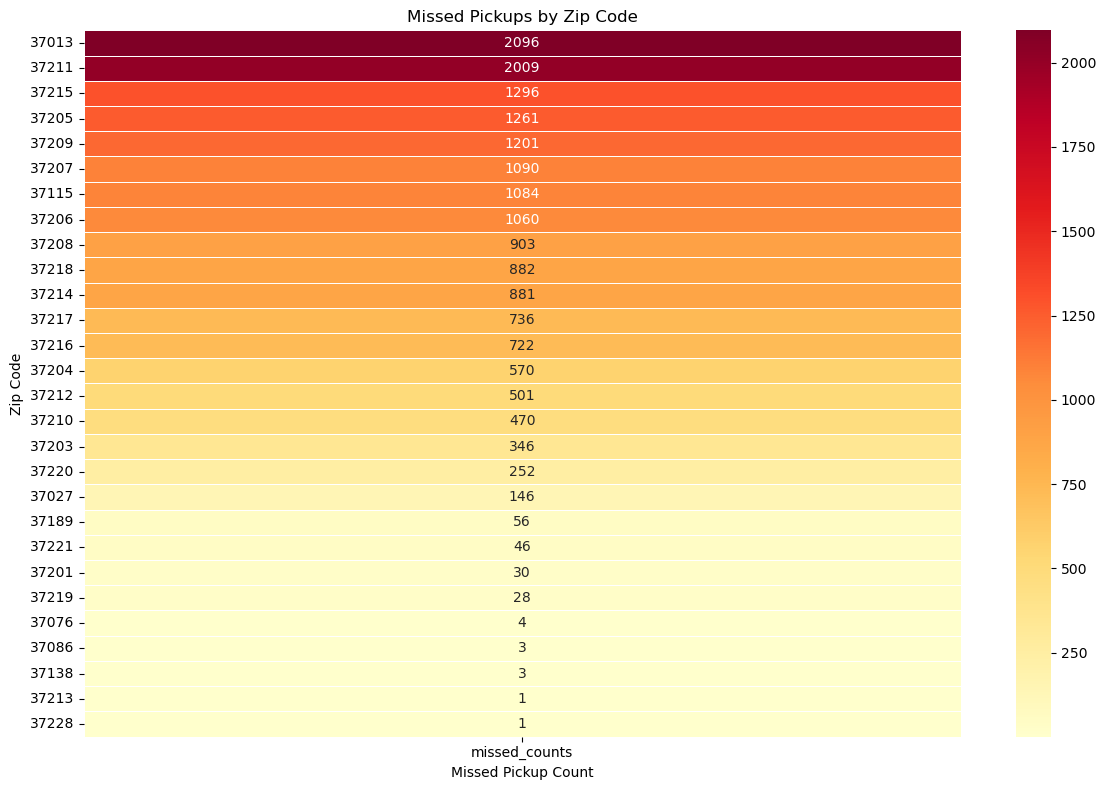

In [46]:
trash_filtered = trash[['Zip Code', 'Date Opened', 'Trash Hauler', 'is_missed_pickup']].dropna(subset=['Zip Code'])
trash_filtered['Zip Code'] = trash_filtered['Zip Code'].astype(int)

# count missed values
missed_counts = trash_filtered[trash_filtered['is_missed_pickup']]['Zip Code'].value_counts().reset_index()
missed_counts.columns = ['Zip Code', 'missed_counts']

# heatmap
plt.figure(figsize=(12, 8))
heatmap = sns.heatmap(
    missed_counts.set_index('Zip Code'),
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5)

plt.title('Missed Pickups by Zip Code')
plt.ylabel('Zip Code')
plt.xlabel('Missed Pickup Count')
plt.tight_layout()

plt.savefig('missed_by_zip.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# Standardize addresses
missed_pickups.loc[:, 'Incident Address'] = missed_pickups['Incident Address'].str.split(',').str[0]
missed_pickups['Incident Address'] = missed_pickups['Incident Address'].astype(str).str.upper().str.strip()
# filtering columns
missed_pickups = missed_pickups.loc[:, ['Zip Code', 'Date Opened', 'Incident Address', 'Trash Hauler', 'is_missed_pickup']]
# Cast Zip to integer
missed_pickups.dropna(subset=['Zip Code'], inplace=True)
missed_pickups['Zip Code'] = missed_pickups['Zip Code'].astype(int)

In [32]:
address_counts = missed_pickups.groupby(['Incident Address', 'Zip Code']).size().reset_index(name='missed_count')

# Calculates fines ($200 for each miss after the first)
address_counts['fines'] = (address_counts['missed_count'] - 1).clip(lower=0) * 200

# Group fines by zip code
fines_by_zip = address_counts.groupby('Zip Code')['fines'].sum().reset_index()
fines_by_zip = fines_by_zip.sort_values('fines', ascending=False)

# fines_by_zip

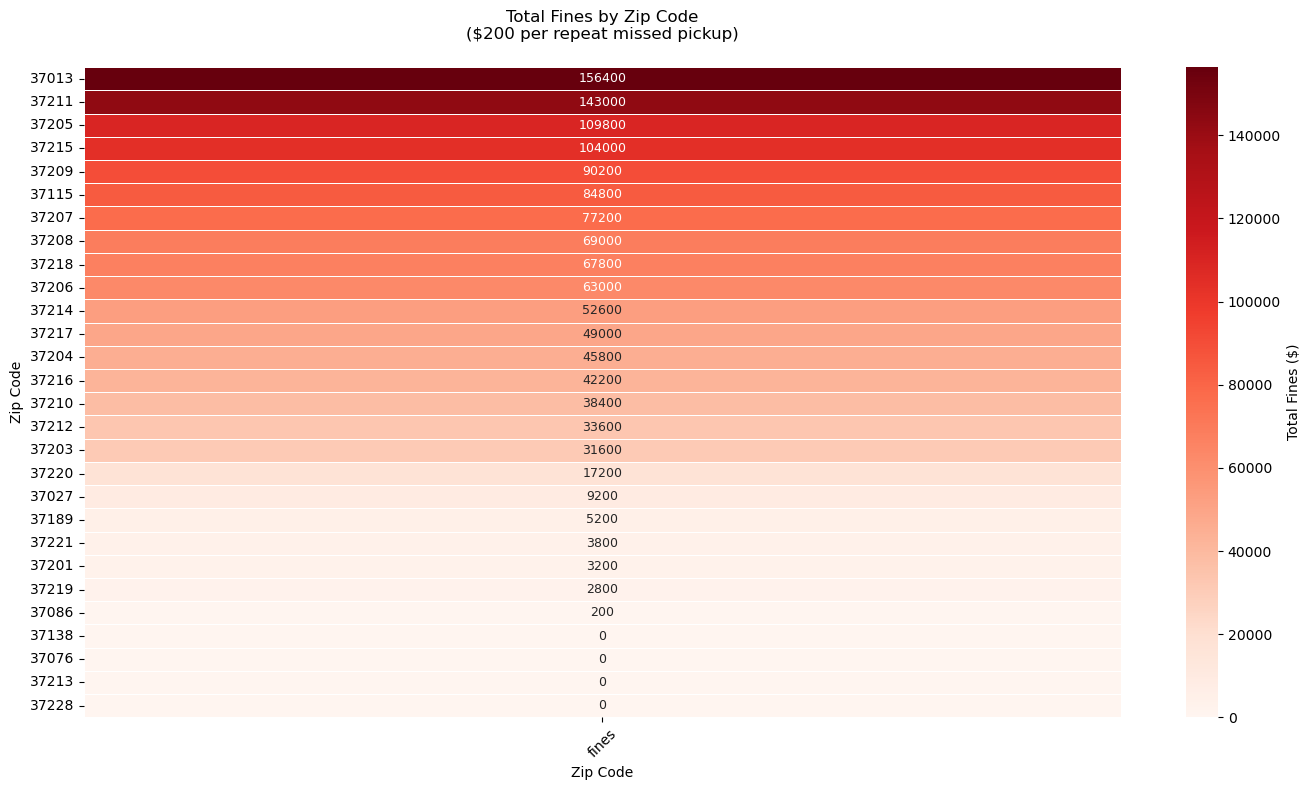

In [48]:
plt.figure(figsize=(14, 8))
heatmap = sns.heatmap(
    fines_by_zip.set_index('Zip Code'), 
    annot=True,
    fmt='.0f',
    cmap='Reds',
    linewidths=0.5,
    cbar_kws={'label': 'Total Fines ($)'},
    annot_kws={'size': 9}
)

plt.title('Total Fines by Zip Code\n($200 per repeat missed pickup)', pad=20)
plt.xlabel('Zip Code')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fines_by_zip.png', dpi=300, bbox_inches='tight')
plt.show()